# Multiband parametric fit: RAINBOW model

[`RainbowFit`](../api/#light_curve.RainbowFit) fits a physical **blackbody + bolometric-light-curve** model to multi-band
photometric time series. It is designed for extragalactic transients such as supernovae,
kilonovae, or tidal disruption events, where the SED is well approximated by a Planck
function whose temperature and luminosity evolve with time.

The method is described in [Russeil et al. 2024](https://ui.adsabs.harvard.edu/abs/2024A%26A...683A.251R/abstract).

## Prerequisites

[`RainbowFit`](../api/#light_curve.RainbowFit) requires [`iminuit`](https://iminuit.readthedocs.io/) ≥ 2.21.
Install it together with all optional dependencies:

```sh
pip install "light-curve[full]"
```

or separately:

```sh
pip install iminuit
```

In [1]:
# %pip install light-curve

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from light_curve import RainbowFit

## Generating synthetic supernova data

We simulate a Bazin-shaped bolometric light curve with a sigmoid temperature evolution,
observed in four LSST-like bands (*g r i z*). Observations are flux densities — not
magnitudes — because `RainbowFit` works in linear flux space.

### Physical parameters

| Parameter | Symbol | Value |
|-----------|--------|-------|
| Peak time | $t_0$ | 60 000 (MJD) |
| Amplitude | $A$ | 1.0 |
| Rise time | $t_\text{rise}$ | 5 d |
| Fall time | $t_\text{fall}$ | 30 d |
| Min temperature | $T_\text{min}$ | 5 000 K |
| Max temperature | $T_\text{max}$ | 15 000 K |
| Colour timescale | $t_\text{color}$ | 10 d |

In [3]:
rng = np.random.default_rng(0)

# Effective wavelengths in Angstrom for griz
band_wave_aa = {"g": 4770.0, "r": 6231.0, "i": 7625.0, "z": 9134.0}

# True parameters
reference_time = 60_000.0
amplitude      = 1.0
rise_time      = 5.0
fall_time      = 30.0
Tmin           = 5_000.0
Tmax           = 15_000.0
t_color        = 10.0

# Per-band baseline flux (constant offset)
baselines = {b: 0.3 * amplitude + rng.exponential(scale=0.3 * amplitude) for b in band_wave_aa}

# Build the feature object first so we can use .model() to generate data
feature = RainbowFit.from_angstrom(
    band_wave_aa,
    with_baseline=True,
    bolometric="bazin",
    temperature="sigmoid",
)

# True parameter vector: common + bolometric + temperature + baselines + chi2_placeholder
true_params = [
    reference_time, amplitude, rise_time, fall_time,  # Bazin bolometric
    Tmin, Tmax, t_color,                              # sigmoid temperature
    *baselines.values(),                               # per-band baselines
    1.0,                                               # reduced chi^2 placeholder
]

# Random observation times covering ±3 rise/fall windows
n_obs = 1000
t    = np.sort(rng.uniform(reference_time - 3 * rise_time, reference_time + 3 * fall_time, n_obs))
band = rng.choice(list(band_wave_aa), size=n_obs)

# True model flux
flux = feature.model(t, band, *true_params)

# Poisson-like noise: S/N=10 at minimum flux
flux_err = np.sqrt(flux * np.min(flux)) / 10.0
flux = flux + rng.normal(0.0, flux_err)

print(f"Generated {n_obs} observations in bands {list(band_wave_aa)}")

Generated 1000 observations in bands ['g', 'r', 'i', 'z']


/home/etru7215/Documents/NOMAI_LSST/modified_blackbody/light-curve-python/light-curve/light_curve/light_curve_py/warnings.py:19: ExperimentalWarning: Function light_curve.light_curve_py.features.rainbow.generic.RainbowFit is experimental and may cause any kind of troubles
  warn_experimental(message)


## Fitting the light curve

Call `feature(t, flux, sigma=flux_err, band=band)`. The result is a NumPy array of
fit parameters followed by the **reduced χ²** of the fit.

In [4]:
result = feature(t, flux, sigma=flux_err, band=band)

# Parameter names are stored in feature.names
print("Parameter names:", feature.names)
print()
for name, val, true in zip(feature.names, result, true_params):
    print(f"  {name:25s}  fitted={val:10.3f}  true={true:10.3f}")

Parameter names: ['reference_time', 'amplitude', 'rise_time', 'fall_time', 'Tmin', 'Tmax', 't_color', 'baseline_g', 'baseline_r', 'baseline_i', 'baseline_z']

  reference_time             fitted= 59999.735  true= 60000.000
  amplitude                  fitted=     0.969  true=     1.000
  rise_time                  fitted=     5.321  true=     5.000
  fall_time                  fitted=    31.926  true=    30.000
  Tmin                       fitted=  4948.538  true=  5000.000
  Tmax                       fitted= 14263.650  true= 15000.000
  t_color                    fitted=    10.271  true=    10.000
  baseline_g                 fitted=     0.500  true=     0.504
  baseline_r                 fitted=     0.588  true=     0.606
  baseline_i                 fitted=     0.294  true=     0.306
  baseline_z                 fitted=     0.286  true=     0.301


## Visualising the fit

Plot the data and the best-fit model curve for each band.

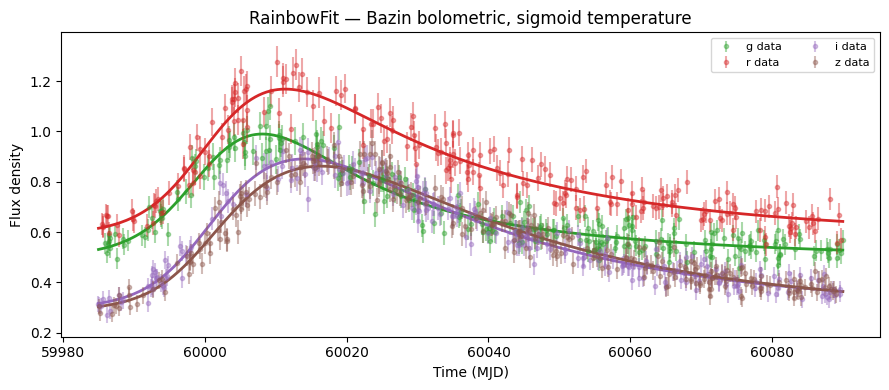

In [5]:
colors = {"g": "#2ca02c", "r": "#d62728", "i": "#9467bd", "z": "#8c564b"}

fig, ax = plt.subplots(figsize=(9, 4))

t_grid = np.linspace(t.min(), t.max(), 400)

for b in band_wave_aa:
    mask = band == b
    ax.errorbar(
        t[mask], flux[mask], yerr=flux_err[mask],
        fmt=".", color=colors[b], alpha=0.4, label=f"{b} data",
    )
    band_grid = np.full(len(t_grid), b)
    ax.plot(t_grid, feature.model(t_grid, band_grid, *result), color=colors[b], lw=2)

ax.set_xlabel("Time (MJD)")
ax.set_ylabel("Flux density")
ax.set_title("RainbowFit — Bazin bolometric, sigmoid temperature")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Parameter uncertainties

`fit_and_get_errors` returns a `(params, errors)` tuple. The errors are estimated by
`iminuit` from the Hessian of the chi-squared surface.

In [6]:
params, errors = feature.fit_and_get_errors(t, flux, sigma=flux_err, band=band)

print(f"{'Parameter':25s}  {'Value':>10s}  {'Error':>10s}  {'True':>10s}")
print("-" * 62)
for name, val, err, true in zip(feature.names, params, errors, true_params):
    print(f"{name:25s}  {val:10.3f}  {err:10.3f}  {true:10.3f}")

Parameter                       Value       Error        True
--------------------------------------------------------------
reference_time              59999.735       0.607   60000.000
amplitude                       0.969       0.021       1.000
rise_time                       5.321       0.234       5.000
fall_time                      31.926       0.881      30.000
Tmin                         4948.538     195.545    5000.000
Tmax                        14263.650     885.755   15000.000
t_color                        10.271       0.961      10.000
baseline_g                      0.500       0.037       0.504
baseline_r                      0.588       0.037       0.606
baseline_i                      0.294       0.034       0.306
baseline_z                      0.286       0.036       0.301


## Peak time

The bolometric peak time can differ from `reference_time` for asymmetric light curves.
`feature.peak_time(params)` computes it analytically from the bolometric term.

In [7]:
t_peak = feature.peak_time(params)
print(f"Fitted peak time : {t_peak:.2f} MJD")
print(f"True   peak time : {feature.peak_time(np.array(true_params)):.2f} MJD")

Fitted peak time : 60007.91 MJD
True   peak time : 60007.68 MJD


## Choosing different models

`RainbowFit` accepts pluggable **bolometric**, **temperature**, and **spectral** terms.

### Bolometric terms

| Name | Parameters | Description |
|------|-----------|-------------|
| `'bazin'` (default) | `reference_time, amplitude, rise_time, fall_time` | Bazin 2011 rise-and-fall |
| `'sigmoid'` | `reference_time, amplitude, rise_time` | Logistic rise only |
| `'linexp'` | `reference_time, amplitude, rise_time` | Linear rise, exponential decay |
| `'doublexp'` | `reference_time, amplitude, time1, time2, p` | Exponential rise, decay with two exponentials |

### Temperature terms

| Name | Parameters | Description |
|------|-----------|-------------|
| `'sigmoid'` (default) | `Tmin, Tmax, t_color` | Temperature drops sigmoidally from $T_\text{max}$ to $T_\text{min}$ |
| `'constant'` | `T` | Fixed temperature |
| `'delayed_sigmoid'` | `Tmin, Tmax, t_color, t_delay` | Sigmoid delayed relative to bolometric peak |

### Spectral terms

| Name | Parameters | Description |
|------|-----------|-------------|
| `'planck'` (default) | *(none)* | Standard blackbody $B_\nu(T)$ — no extra parameters |
| `'blanketed'` | `lambda_scale` | lambda\_scale from 0 (no extinction) to 1 (high UV extinction)|

In [8]:
# Constant temperature — fewer parameters, useful for bluer transients
feature_const_T = RainbowFit.from_angstrom(
    band_wave_aa,
    with_baseline=False,
    bolometric="bazin",
    temperature="constant",
)
result_const = feature_const_T(t, flux, sigma=flux_err, band=band)
print("Parameters (constant T model):")
for name, val in zip(feature_const_T.names, result_const):
    print(f"  {name:25s}  {val:.3f}")

Parameters (constant T model):
  reference_time             59994.357
  amplitude                  2.007
  rise_time                  8.794
  fall_time                  87.390
  T                          9255.715


In [10]:
# Blanketed blackbody — adds UV extinction parameters: lambda_scale
feature_blanketed = RainbowFit.from_angstrom(
    band_wave_aa,
    with_baseline=False,
    bolometric="bazin",
    temperature="sigmoid",
    spectral="blanketed",
)
result_blanketed = feature_blanketed(t, flux, sigma=flux_err, band=band)
print("Parameters (blanketed spectral model):")
for name, val in zip(feature_blanketed.names, result_blanketed):
    print(f"  {name:25s}  {val:.3f}")

Parameters (blanketed spectral model):
  reference_time             59990.533
  amplitude                  4.758
  rise_time                  9.849
  fall_time                  87.211
  Tmin                       13899.764
  Tmax                       19401.646
  t_color                    7.187
  lambda_scale               0.246


## See also

- [RainbowFit API reference](../api/#light_curve.RainbowFit)
- [Feature table](../../) — all extractors
- [Parametric fits tutorial](../../fitting/) — single-band transient fits